In [3]:
from google.colab import files
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
!pip install category-encoders

uploaded = files.upload()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.6 MB/s eta 0:00:00


Saving Cars Datasets 2025.csv to Cars Datasets 2025.csv


In [4]:
import pandas as pd

df = pd.read_csv('Cars Datasets 2025.csv', encoding='latin1')
display(df.head())

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [5]:
# Print duplicate rows
duplicate_rows_df = df[df.duplicated()]
display(duplicate_rows_df)

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
336,Volkswagen,Golf Cabriolet,1.2L I4 Turbo / 2.0L I4 Turbo,1197 cc / 1984 cc,105 - 210 hp,217 km/h,8.4 sec,"$30,000",Petrol,4,200 Nm
354,Volkswagen,Jetta Hybrid,1.4L I4 Turbo + Electric Motor,1395 cc,170 hp,210 km/h,8.6 sec,"$28,000",Hybrid,5,250 Nm
658,Tata Motors,Tiago EV,Permanent Magnet Synchronous,24 kWh,74 hp,120 km/h,5.7 sec,"$11,000",Electric,5,114 Nm
755,Chevrolet,Tahoe RST,5.3L V8 Gasoline,5300 cc,355 hp,180 km/h,7.4 sec,"$64,100",Petrol,7,519 Nm


In [6]:
# Count how many times each duplicate row appears
duplicate_counts = df[df.duplicated(keep=False)].groupby(df.columns.tolist()).size().reset_index(name='count')
display(duplicate_counts)

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque,count
0,Chevrolet,Tahoe RST,5.3L V8 Gasoline,5300 cc,355 hp,180 km/h,7.4 sec,"$64,100",Petrol,7,519 Nm,2
1,Tata Motors,Tiago EV,Permanent Magnet Synchronous,24 kWh,74 hp,120 km/h,5.7 sec,"$11,000",Electric,5,114 Nm,2
2,Volkswagen,Golf Cabriolet,1.2L I4 Turbo / 2.0L I4 Turbo,1197 cc / 1984 cc,105 - 210 hp,217 km/h,8.4 sec,"$30,000",Petrol,4,200 Nm,2
3,Volkswagen,Jetta Hybrid,1.4L I4 Turbo + Electric Motor,1395 cc,170 hp,210 km/h,8.6 sec,"$28,000",Hybrid,5,250 Nm,2


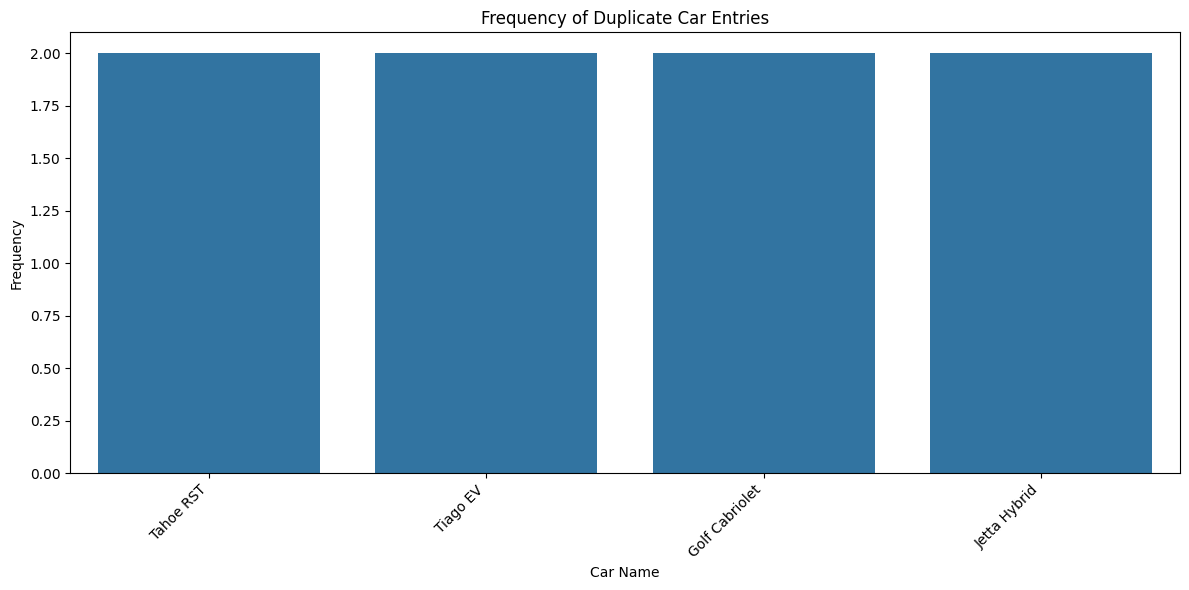

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Cars Names', y='count', data=duplicate_counts)
plt.title('Frequency of Duplicate Car Entries')
plt.xlabel('Car Name')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1218
Number of columns: 11


In [9]:
df = df.drop_duplicates()
print(f"Number of rows after dropping duplicates: {df.shape[0]}")
print(f"Number of columns after dropping duplicates: {df.shape[1]}")

Number of rows after dropping duplicates: 1214
Number of columns after dropping duplicates: 11


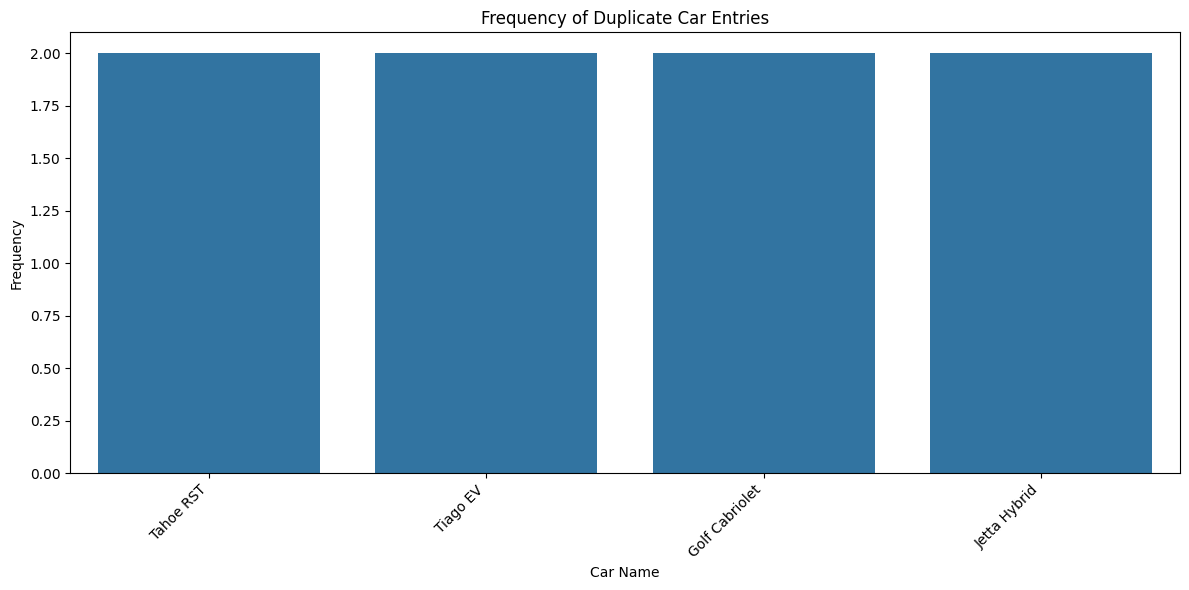

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Cars Names', y='count', data=duplicate_counts)
plt.title('Frequency of Duplicate Car Entries')
plt.xlabel('Car Name')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
missing_values_count = df.isnull().sum()
display(missing_values_count)

,0
Company Names,0
Cars Names,0
Engines,0
CC/Battery Capacity,3
HorsePower,0
Total Speed,0
Performance(0 - 100 )KM/H,6
Cars Prices,0
Fuel Types,0
Seats,0


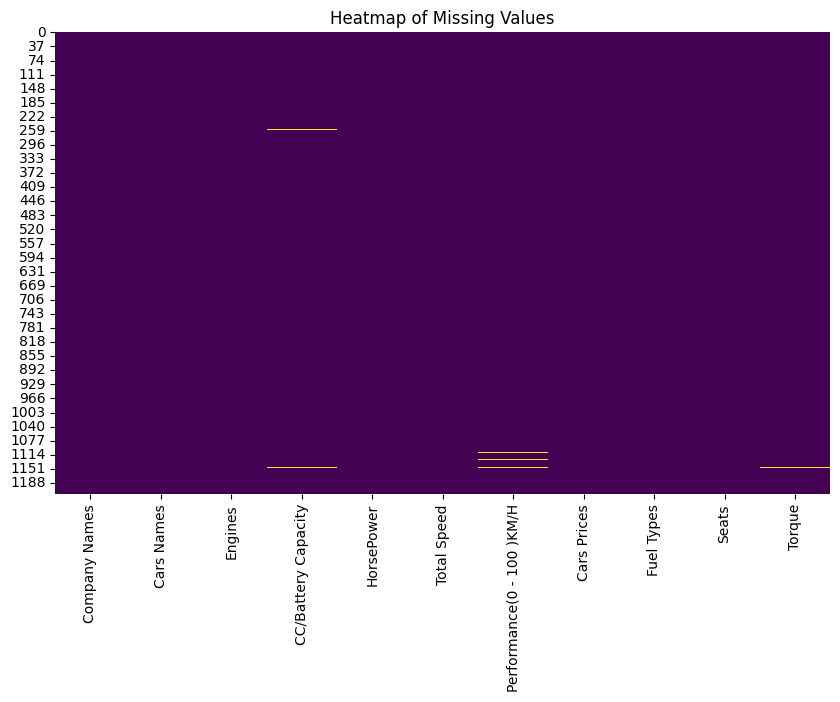

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

In [13]:
# Clean the 'CC/Battery Capacity' column by removing non-numeric characters and converting to numeric
df['CC/Battery Capacity'] = df['CC/Battery Capacity'].astype(str).str.replace('[^\d\.]', '', regex=True)
df['CC/Battery Capacity'] = pd.to_numeric(df['CC/Battery Capacity'], errors='coerce')

# Calculate the mean of 'CC/Battery Capacity'
mean_cc = df['CC/Battery Capacity'].mean()

# Fill missing values with the mean
df['CC/Battery Capacity'].fillna(mean_cc, inplace=True)

# Verify that missing values have been filled
display(df.isnull().sum())

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3980121320.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['CC/Battery Capacity'] = df['CC/Battery Capacity'].astype(str).str.replace('[^\d\.]', '', regex=True)
/tmp/ipython-input-3980121320.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CC/Battery Capacity'].fillna(mean_cc, inplace=True)


,0
Company Names,0
Cars Names,0
Engines,0
CC/Battery Capacity,0
HorsePower,0
Total Speed,0
Performance(0 - 100 )KM/H,6
Cars Prices,0
Fuel Types,0
Seats,0


In [14]:
# Clean the 'Performance(0 - 100 )KM/H' column by removing non-numeric characters and converting to numeric
df['Performance(0 - 100 )KM/H'] = df['Performance(0 - 100 )KM/H'].astype(str).str.replace('[^\d\.]', '', regex=True)
df['Performance(0 - 100 )KM/H'] = pd.to_numeric(df['Performance(0 - 100 )KM/H'], errors='coerce')

# Calculate the mean of 'Performance(0 - 100 )KM/H'
mean_performance = df['Performance(0 - 100 )KM/H'].mean()

# Fill missing values with the mean
df['Performance(0 - 100 )KM/H'].fillna(mean_performance, inplace=True)

# Verify that missing values have been filled
display(df.isnull().sum())

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3109570758.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['Performance(0 - 100 )KM/H'] = df['Performance(0 - 100 )KM/H'].astype(str).str.replace('[^\d\.]', '', regex=True)
/tmp/ipython-input-3109570758.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Performance(0 - 100 )KM/H'].fillna(mean_performance, inplace=True)


,0
Company Names,0
Cars Names,0
Engines,0
CC/Battery Capacity,0
HorsePower,0
Total Speed,0
Performance(0 - 100 )KM/H,0
Cars Prices,0
Fuel Types,0
Seats,0


In [15]:
# Clean the 'Torque' column by removing non-numeric characters and converting to numeric
df['Torque'] = df['Torque'].astype(str).str.replace('[^\d\.]', '', regex=True)
df['Torque'] = pd.to_numeric(df['Torque'], errors='coerce')

# Calculate the mean of 'Torque'
mean_torque = df['Torque'].mean()

# Fill missing values with the mean
df['Torque'].fillna(mean_torque, inplace=True)

# Verify that missing values have been filled
display(df.isnull().sum())

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-799312656.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['Torque'] = df['Torque'].astype(str).str.replace('[^\d\.]', '', regex=True)
/tmp/ipython-input-799312656.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Torque'].fillna(mean_torque, inplace=True)


,0
Company Names,0
Cars Names,0
Engines,0
CC/Battery Capacity,0
HorsePower,0
Total Speed,0
Performance(0 - 100 )KM/H,0
Cars Prices,0
Fuel Types,0
Seats,0


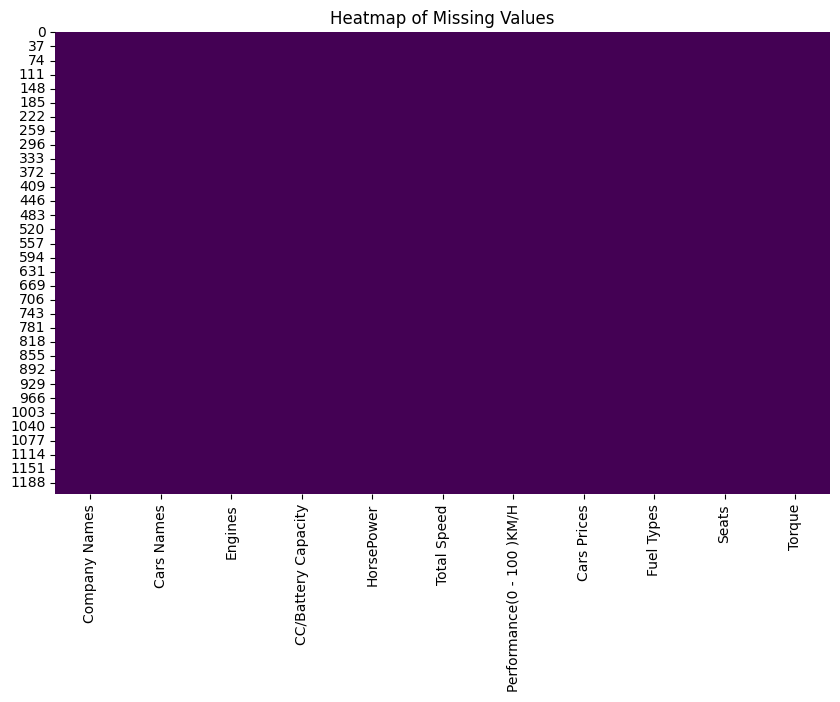

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.show()

Processing column: CC/Battery Capacity
Number of rows before removing outliers for CC/Battery Capacity: 1214
Number of rows after removing outliers for CC/Battery Capacity: 1095


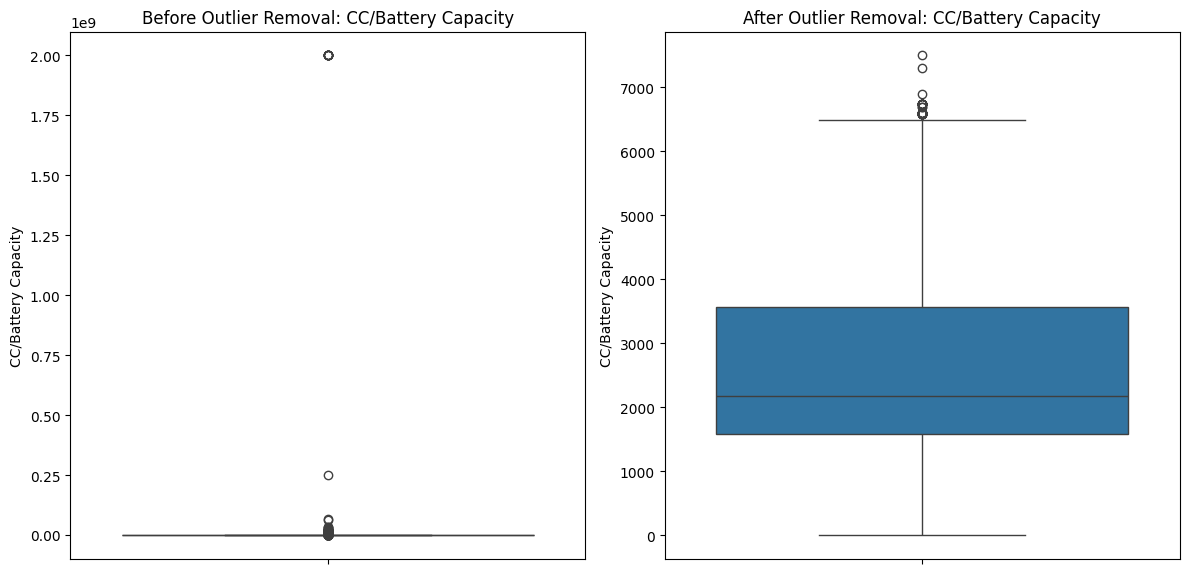

Processing column: Performance(0 - 100 )KM/H
Number of rows before removing outliers for Performance(0 - 100 )KM/H: 1095
Number of rows after removing outliers for Performance(0 - 100 )KM/H: 1078


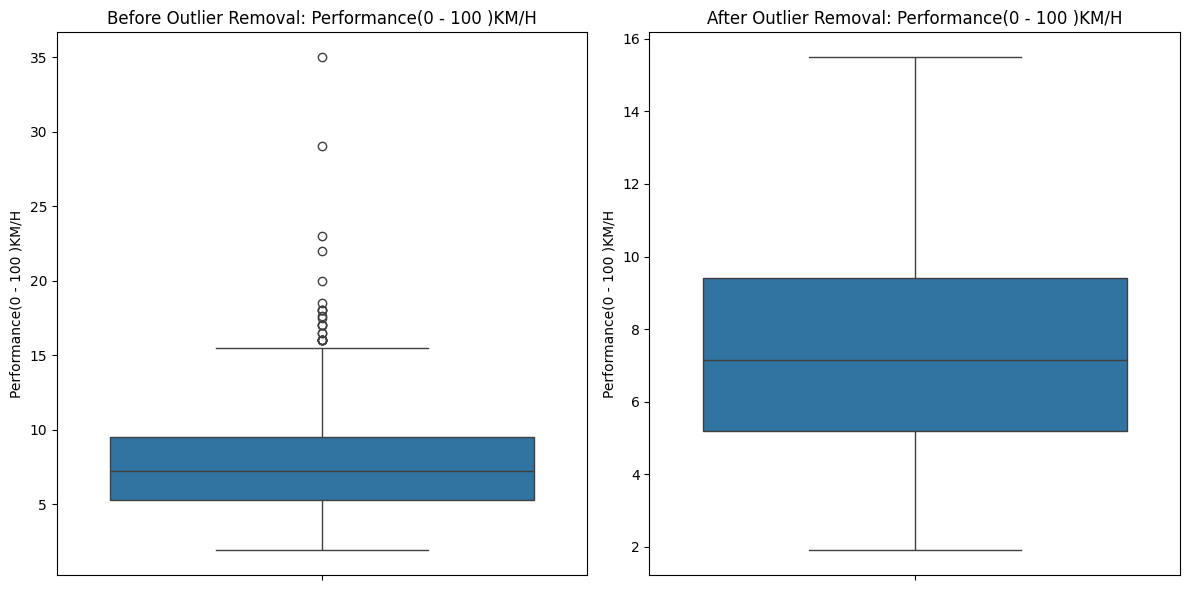

Processing column: Torque
Number of rows before removing outliers for Torque: 1078
Number of rows after removing outliers for Torque: 1054


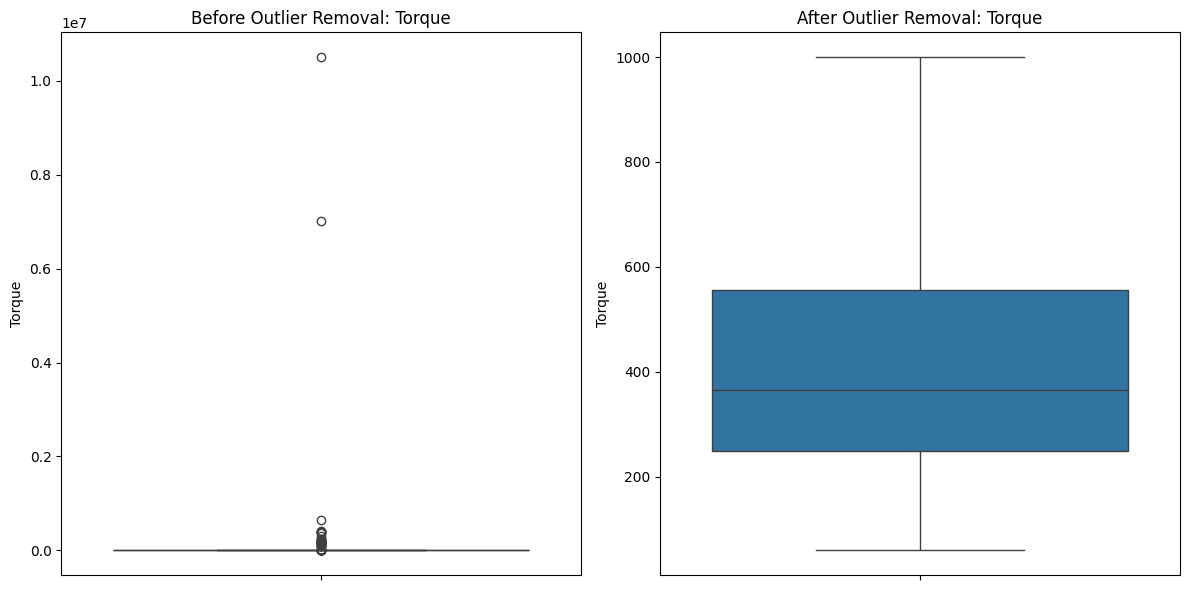

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990.0,963 hp,340 km/h,2.5,"$1,100,000",plug in hyrbrid,2,800.0
1,ROLLS ROYCE,PHANTOM,V12,6749.0,563 hp,250 km/h,5.3,"$460,000",Petrol,5,900.0
3,MERCEDES,GT 63 S,V8,3982.0,630 hp,250 km/h,3.2,"$161,000",Petrol,4,900.0
4,AUDI,AUDI R8 Gt,V10,5204.0,602 hp,320 km/h,3.6,"$253,290",Petrol,2,560.0
5,BMW,Mclaren 720s,V8,3994.0,710 hp,341 km/h,2.9,"$499,000",Petrol,2,770.0


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the dataframe (copied from a previous cell)
df = pd.read_csv('edited_dataset_features (3).csv', encoding='latin1')

df_cleaned = df.copy()

for col in df.select_dtypes(include=np.number).columns:
    print(f"Processing column: {col}")

    # Plot boxplot before outlier removal
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.boxplot(y=df[col])
    plt.title(f'Before Outlier Removal: {col}')
    plt.xticks(rotation=45)

    # Calculate Q1, Q3, and IQR
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter outliers
    initial_rows = len(df_cleaned)
    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    rows_after_removal = len(df_cleaned)
    print(f"Number of rows before removing outliers for {col}: {initial_rows}")
    print(f"Number of rows after removing outliers for {col}: {rows_after_removal}")

    # Plot boxplot after outlier removal
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_cleaned[col])
    plt.title(f'After Outlier Removal: {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

display(df_cleaned.head())

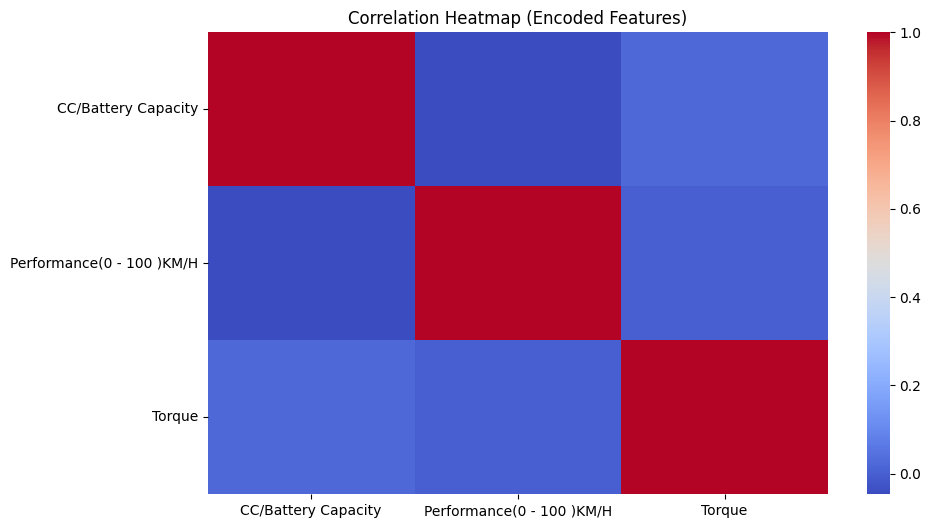

In [19]:
# Correlation Heatmap (before encoding)
plt.figure(figsize=(10,6))

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Encoded Features)")
plt.show()

In [20]:
# Identify categorical columns
cat_cols = ["Company Names", "Cars Names", "Engines", "Fuel Types"]

In [21]:
# Label Encoding (Company Names, Engines)
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in ["Company Names", "Engines"]:
    le = LabelEncoder()
    df[col + "_Label"] = le.fit_transform(df[col])
    label_encoders[col] = le

print("After Label Encoding:")
print(df[["Company Names", "Company Names_Label", "Engines", "Engines_Label"]].head())

After Label Encoding:
  Company Names  Company Names_Label      Engines  Engines_Label
0       FERRARI                    8           V8            353
1   ROLLS ROYCE                   28          V12            345
2          Ford                    9  1.2L Petrol             26
3      MERCEDES                   21           V8            353
4          AUDI                    1          V10            344


In [22]:
# One-Hot Encoding (Fuel Types)
onehot = pd.get_dummies(df["Fuel Types"], prefix="Fuel")
df = pd.concat([df, onehot], axis=1)

print("After One-Hot Encoding (Fuel Types):")
print(df[["Fuel Types"] + list(onehot.columns)].head())

After One-Hot Encoding (Fuel Types):
        Fuel Types  Fuel_CNG/Petrol  Fuel_Diesel  Fuel_Diesel Hybrid  \
0  plug in hyrbrid            False        False               False   
1           Petrol            False        False               False   
2           Petrol            False        False               False   
3           Petrol            False        False               False   
4           Petrol            False        False               False   

   Fuel_Diesel/Petrol  Fuel_Electric  Fuel_Gas / Hybrid  Fuel_Hybrid  \
0               False          False              False        False   
1               False          False              False        False   
2               False          False              False        False   
3               False          False              False        False   
4               False          False              False        False   

   Fuel_Hybrid (Gas + Electric)  Fuel_Hybrid (Petrol)  ...  Fuel_Petrol  \
0                     

In [23]:
# Target Encoding (Cars Names)

# Clean Cars Prices into numeric for target encoding
df["Cars Prices Clean"] = df["Cars Prices"].replace(r'[\\$,]', '', regex=True)
df["Cars Prices Clean"] = df["Cars Prices Clean"].str.replace('-', '').str.replace(' ', '')
df["Cars Prices Clean"] = pd.to_numeric(df["Cars Prices Clean"], errors="coerce")

# Manual Target Encoding: mean price per car name
cars_name_mean = df.groupby("Cars Names")["Cars Prices Clean"].mean()
df["Cars Names_TE"] = df["Cars Names"].map(cars_name_mean)

print("After Target Encoding (Cars Names):")
print(df[["Cars Names", "Cars Names_TE"]].head())

After Target Encoding (Cars Names):
      Cars Names  Cars Names_TE
0  SF90 STRADALE   1.100000e+06
1        PHANTOM   4.600000e+05
2            KA+   1.200015e+09
3        GT 63 S   1.610000e+05
4     AUDI R8 Gt   2.532900e+05


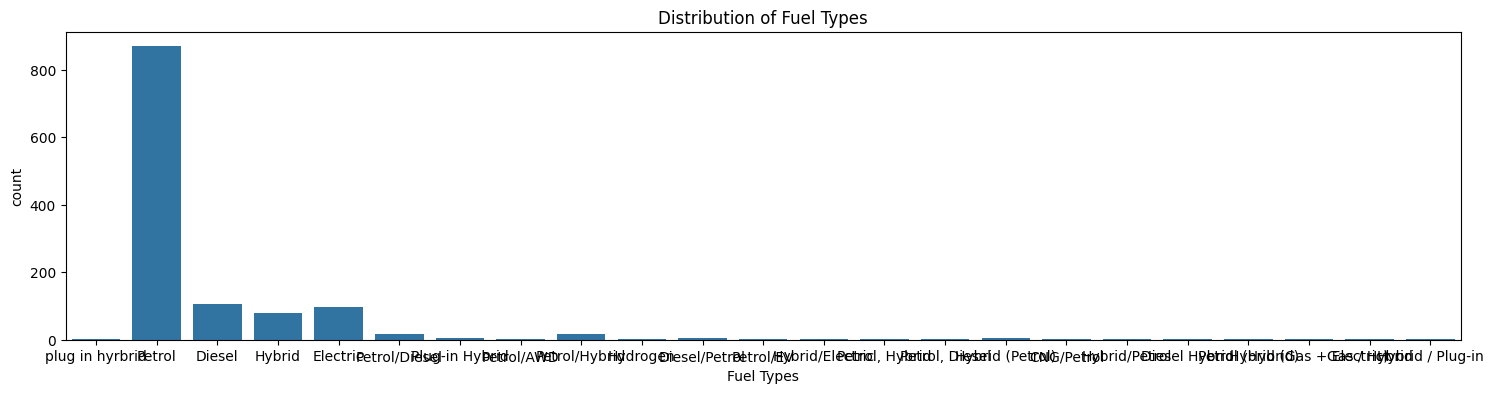

In [24]:
# Distribution of Fuel Types
plt.figure(figsize=(18,4))
sns.countplot(x="Fuel Types", data=df)
plt.title("Distribution of Fuel Types")
plt.show()

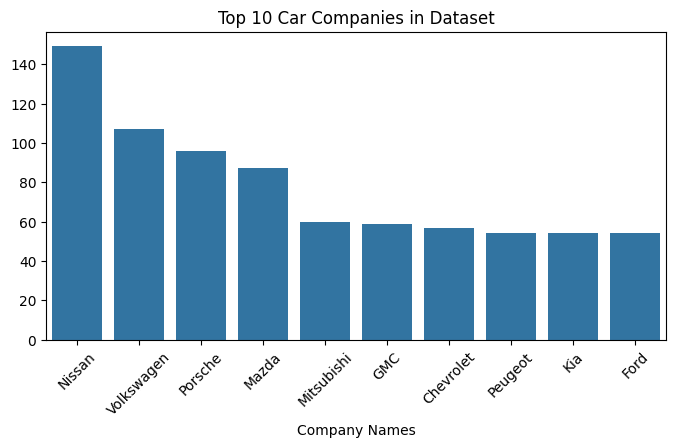

In [25]:
# Top 10 Company Names
top_companies = df["Company Names"].value_counts().nlargest(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_companies.index, y=top_companies.values)
plt.title("Top 10 Car Companies in Dataset")
plt.xticks(rotation=45)
plt.show()

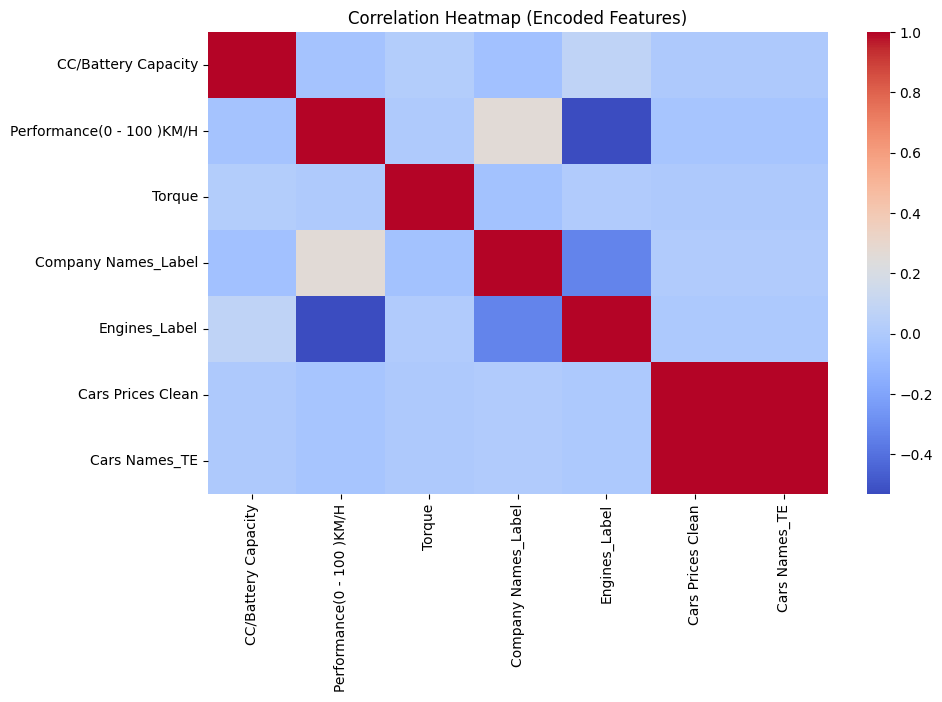

In [26]:
# Correlation Heatmap (after encoding)
plt.figure(figsize=(10,6))

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Encoded Features)")
plt.show()

In [27]:
numerical_features = ['CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Torque']
target = 'Cars Prices Clean'

In [28]:
# Function to parse range values (e.g., '150 - 280' -> mean of 150 and 280)
def parse_range(value):
    try:
        # Remove ' hp' or ' km/h' if present
        value = value.replace(' hp', '').replace(' km/h', '').strip()
        # Check if the value contains a range (e.g., '150 - 280')
        if '-' in value:
            # Split the range and compute the mean
            low, high = map(float, value.split('-'))
            return (low + high) / 2
        # If not a range, convert directly to float
        return float(value)
    except Exception as e:
        print(f"Error parsing value '{value}': {e}")
        return np.nan  # Return NaN for invalid values

In [29]:
# Validate column existence
if not all(col in df.columns for col in numerical_features + [target]):
    raise ValueError("One or more specified columns not found in dataset")

In [30]:
# Clean and convert 'HorsePower' and 'Total Speed' columns
df['HorsePower'] = df['HorsePower'].apply(parse_range)
df['Total Speed'] = df['Total Speed'].apply(parse_range)

Error parsing value '2488 cc': could not convert string to float: '2488 cc'
Error parsing value '~170': could not convert string to float: '~170'
Error parsing value '122 HP': could not convert string to float: '122 HP'
Error parsing value '100 HP': could not convert string to float: '100 HP'
Error parsing value '400 HP': could not convert string to float: '400 HP'
Error parsing value '156 HP': could not convert string to float: '156 HP'
Error parsing value '260 HP': could not convert string to float: '260 HP'
Error parsing value '300 HP': could not convert string to float: '300 HP'
Error parsing value '400 HP': could not convert string to float: '400 HP'
Error parsing value '122 HP': could not convert string to float: '122 HP'
Error parsing value '201 HP': could not convert string to float: '201 HP'
Error parsing value '400 HP': could not convert string to float: '400 HP'
Error parsing value '100 HP': could not convert string to float: '100 HP'
Error parsing value '137 HP': could not 

In [31]:
# Check for missing values in selected features and target
print("Missing values in selected features and target:")
print(df[numerical_features + [target]].isnull().sum())

Missing values in selected features and target:
CC/Battery Capacity            0
HorsePower                   189
Total Speed                    1
Performance(0 - 100 )KM/H      0
Torque                         0
Cars Prices Clean              6
dtype: int64


In [32]:
# Handle missing values by dropping rows
df = df.dropna(subset=numerical_features + [target])

In [40]:
# Initialize the StandardScaler# Initialize the StandardScaler
scaler = StandardScaler()

# Scale only the selected numerical features
scaled_features = scaler.fit_transform(df[numerical_features])
scaled_df = pd.DataFrame(scaled_features, columns=numerical_features, index=df.index)

In [41]:
# Add the target variable (unscaled) and other columns back
scaled_df[target] = df[target].values
scaled_df = pd.concat([scaled_df, df.drop(columns=numerical_features + [target])], axis=1)

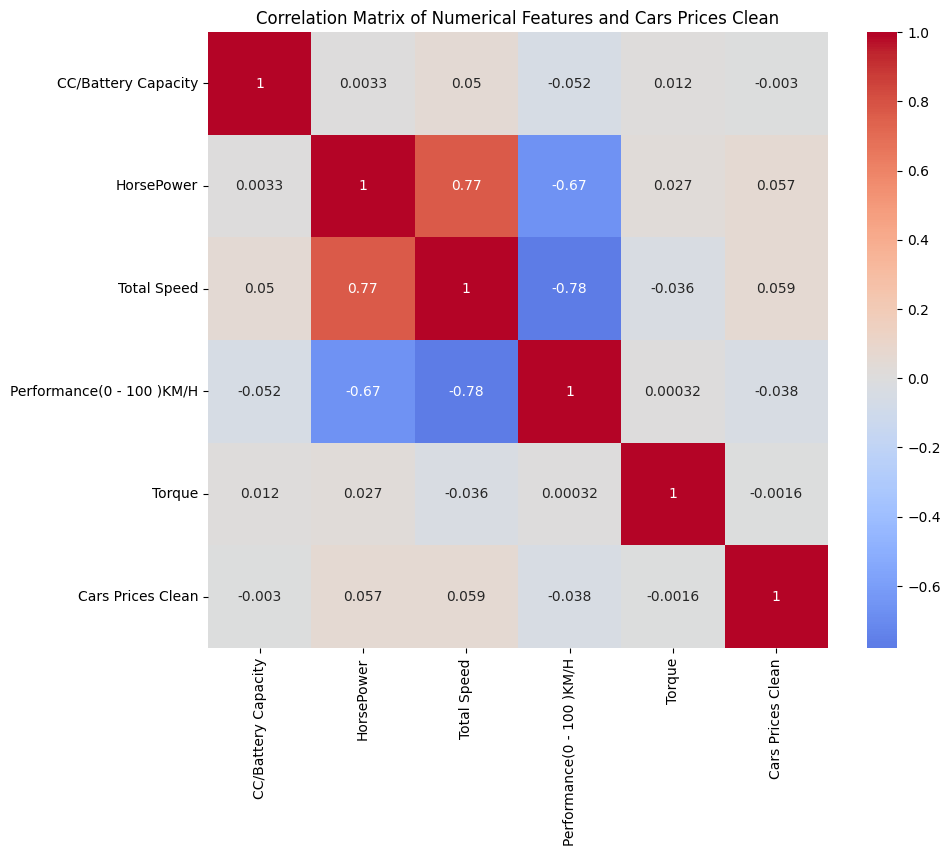

In [42]:
# --- Exploratory Data Analysis (EDA) ---
# Correlation matrix
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features and Cars Prices Clean')
plt.show()

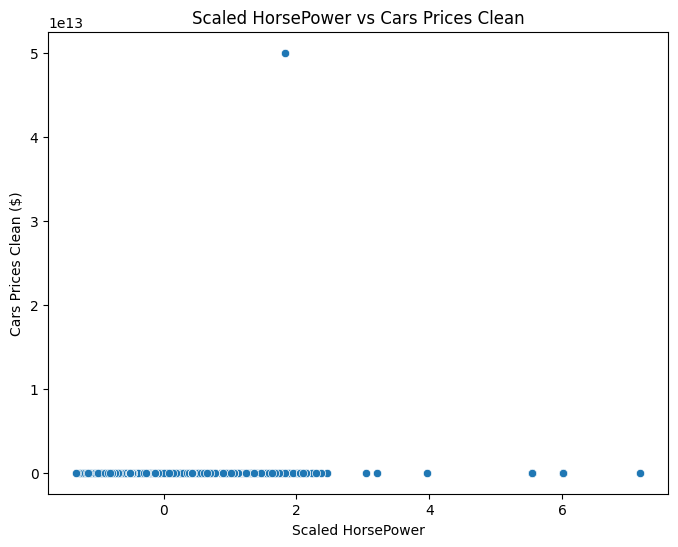

In [43]:
# Scatter plot: HorsePower vs Cars Prices Clean
plt.figure(figsize=(8, 6))
sns.scatterplot(x=scaled_df['HorsePower'], y=scaled_df[target])
plt.title('Scaled HorsePower vs Cars Prices Clean')
plt.xlabel('Scaled HorsePower')
plt.ylabel('Cars Prices Clean ($)')
plt.show()

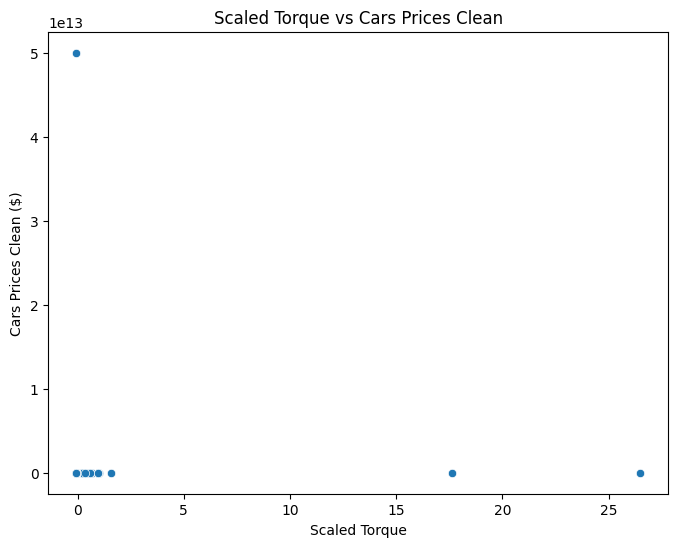

In [44]:
# Scatter plot: Torque vs Cars Prices Clean
plt.figure(figsize=(8, 6))
sns.scatterplot(x=scaled_df['Torque'], y=scaled_df[target])
plt.title('Scaled Torque vs Cars Prices Clean')
plt.xlabel('Scaled Torque')
plt.ylabel('Cars Prices Clean ($)')
plt.show()

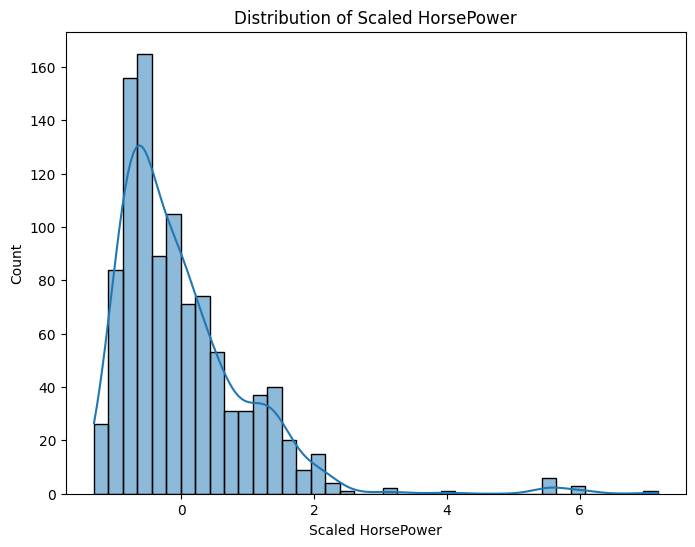

In [45]:
# Distribution plot for Scaled HorsePower
plt.figure(figsize=(8, 6))
sns.histplot(scaled_df['HorsePower'], kde=True)
plt.title('Distribution of Scaled HorsePower')
plt.xlabel('Scaled HorsePower')
plt.show()

In [46]:
# Print summary statistics of scaled features
print("\nSummary statistics of scaled features:")
print(scaled_df[numerical_features].describe())


Summary statistics of scaled features:
       CC/Battery Capacity   HorsePower  Total Speed  \
count          1024.000000  1024.000000  1024.000000   
mean              0.000000     0.000000     0.000000   
std               1.000489     1.000489     1.000489   
min              -0.094712    -1.314311    -2.568697   
25%              -0.094703    -0.690962    -0.707217   
50%              -0.094698    -0.249036    -0.167388   
75%              -0.094688     0.425484     0.595819   
max              11.254712     7.170675     5.249520   

       Performance(0 - 100 )KM/H       Torque  
count               1.024000e+03  1024.000000  
mean                5.551115e-17     0.000000  
std                 1.000489e+00     1.000489  
min                -1.611175e+00    -0.056048  
25%                -6.945049e-01    -0.055527  
50%                -1.139470e-01    -0.055152  
75%                 5.277223e-01    -0.054646  
max                 8.411088e+00    26.472101  


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/scaled_dataset.csv', encoding="utf-8", low_memory=False)

#Convert numeric columns
def to_numeric_clean(s):
    s = s.astype(str).str.replace('[^\d\.]', '', regex=True)
    s = pd.to_numeric(s, errors='coerce')
    return s

df['torque_num'] = to_numeric_clean(df['Torque'])
df['hp_num'] = to_numeric_clean(df['HorsePower'])
df['cc_num'] = to_numeric_clean(df['CC/Battery Capacity'])
df['accel_num'] = to_numeric_clean(df['Performance(0 - 100 )KM/H'])

<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3184503977.py:9: SyntaxWarning: invalid escape sequence '\d'
  s = s.astype(str).str.replace('[^\d\.]', '', regex=True)


In [49]:
# Create new features - Engineered features

df['hp_per_cc']      = df['hp_num'] / df['cc_num'].replace({0: np.nan})
df['accel_score']    = 1 / df['accel_num'].replace({0: np.nan})
df['torque_to_hp']   = df['torque_num'] / df['hp_num'].replace({0: np.nan})

In [50]:
print("Skewness before log transformation:")
print(df.select_dtypes(include=[np.number]).skew())

num_cols = ['hp_num', 'cc_num', 'torque_num', 'accel_num',
            'hp_per_cc', 'torque_to_hp', 'accel_score']

# Compute skewness and sort
skewness = df[num_cols].skew().sort_values(ascending=False)
print("\nSkewness (sorted):\n", skewness)

# Identify skewed features
skewed = skewness[skewness.abs() > 0.75].index.tolist()

# Apply log1p to reduce skewness
for col in skewed:
    if (df[col].dropna() >= 0).mean() > 0.9:  # ensure non-negative
        df[f"{col}_log"] = np.log1p(df[col])
        print(f"Applied log1p to: {col}")

#Preview new columns
print("\nNew columns after log transformation:")
print([c for c in df.columns if c.endswith('_log')])


Skewness before log transformation:
CC/Battery Capacity          0.782308
HorsePower                   1.056347
Total Speed                  0.789741
Performance(0 - 100 )KM/H    0.479415
Torque                       0.642731
torque_num                   0.820025
hp_num                       1.518633
cc_num                       1.068738
accel_num                    0.858254
hp_per_cc                    9.187879
accel_score                  8.527341
torque_to_hp                 7.296027
dtype: float64

Skewness (sorted):
 hp_per_cc       9.187879
accel_score     8.527341
torque_to_hp    7.296027
hp_num          1.518633
cc_num          1.068738
accel_num       0.858254
torque_num      0.820025
dtype: float64
Applied log1p to: hp_per_cc
Applied log1p to: accel_score
Applied log1p to: torque_to_hp
Applied log1p to: hp_num
Applied log1p to: cc_num
Applied log1p to: accel_num
Applied log1p to: torque_num

New columns after log transformation:
['hp_per_cc_log', 'accel_score_log', 'torque_to

In [51]:
display(df.head())

,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Torque,Cars Prices,Company Names,Cars Names,Engines,Fuel Types,...,hp_per_cc,accel_score,torque_to_hp,hp_per_cc_log,accel_score_log,torque_to_hp_log,hp_num_log,cc_num_log,accel_num_log,torque_num_log
0,0.731726,3.779069,2.478679,-1.720920,1.822924,"$1,100,000",FERRARI,SF90 STRADALE,V8,plug in hyrbrid,...,5.164595,0.581085,0.482374,1.818822,0.458111,0.393645,1.564246,0.549119,1.000970,1.037773
1,2.319580,1.509193,0.645809,-0.719085,2.301838,"$460,000",ROLLS ROYCE,PHANTOM,V12,Petrol,...,0.650632,1.390656,1.525212,0.501158,0.871568,0.926325,0.919961,1.199838,0.541792,1.194479
2,0.727122,1.889397,0.645809,-1.470461,2.301838,"$161,000",MERCEDES,GT 63 S,V8,Petrol,...,2.598460,0.680059,1.218293,1.280506,0.518829,0.796738,1.061048,0.546456,0.904405,1.194479
3,1.430405,1.730506,2.071375,-1.327342,0.673530,"$253,290",AUDI,AUDI R8 Gt,V10,Petrol,...,1.209801,0.753385,0.389210,0.792903,0.561548,0.328735,1.004487,0.888058,0.844727,0.514935
4,0.734028,2.343372,2.499044,-1.577801,1.679250,"$499,000",BMW,Mclaren 720s,V8,Petrol,...,3.192483,0.633794,0.716596,1.433293,0.490905,0.540343,1.206980,0.550447,0.946937,0.985537


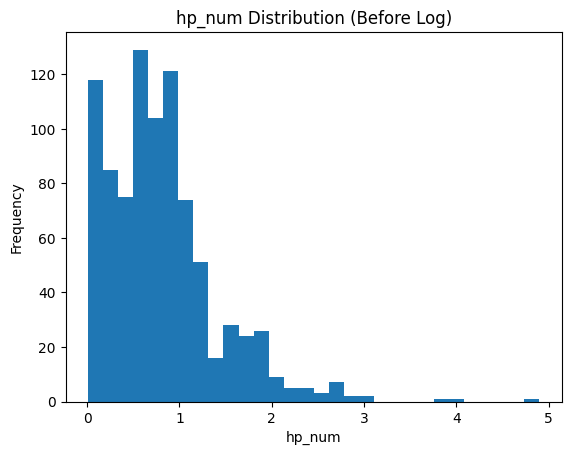

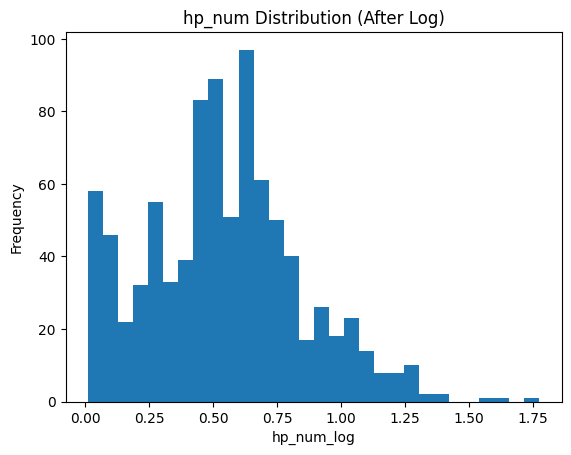

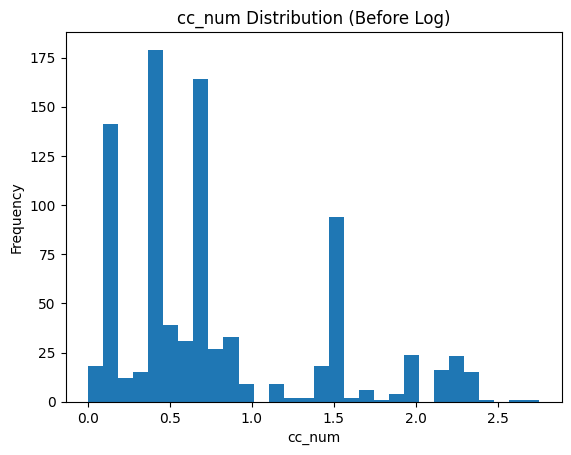

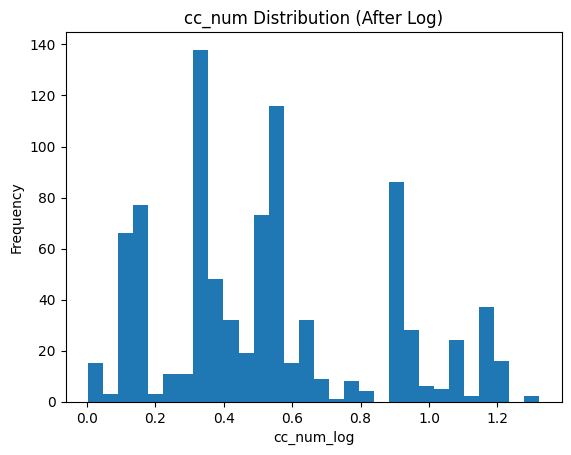

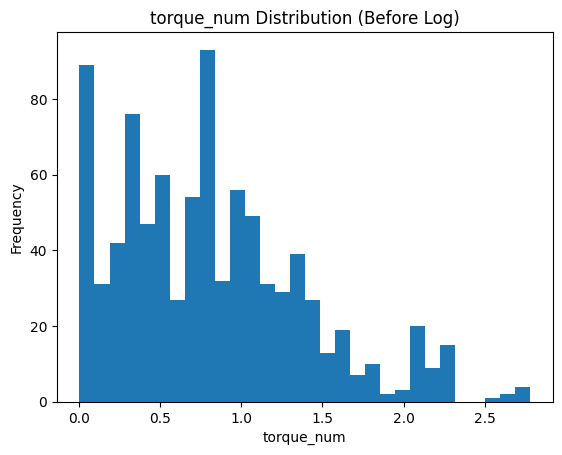

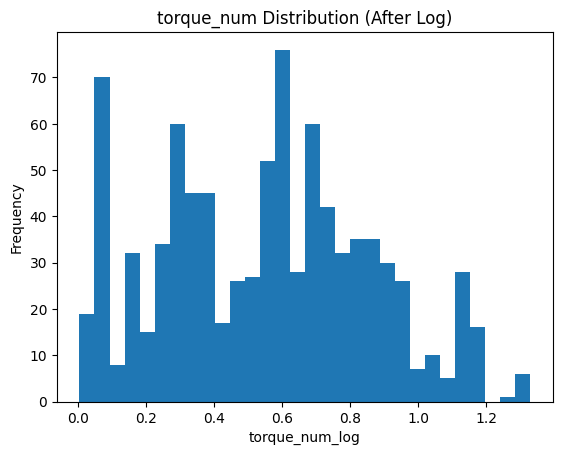

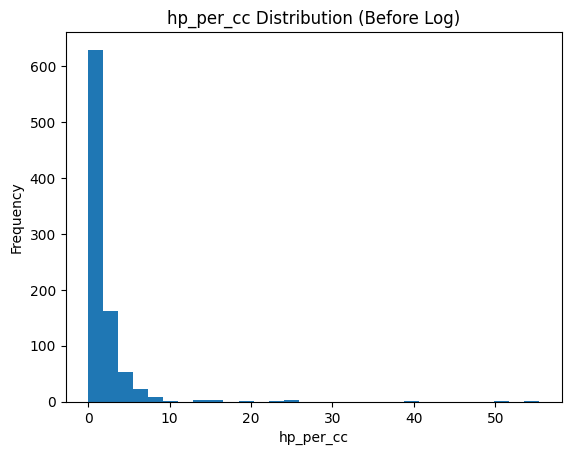

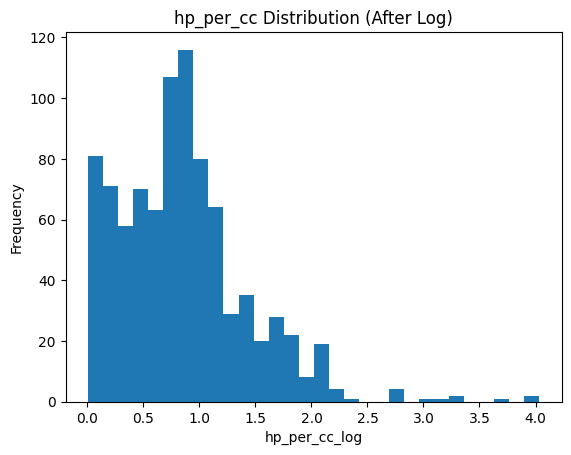

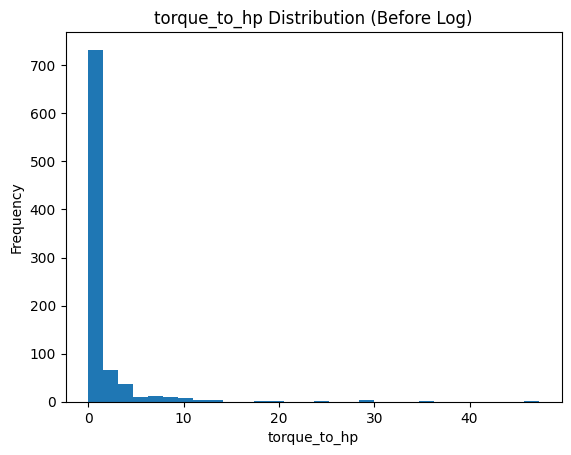

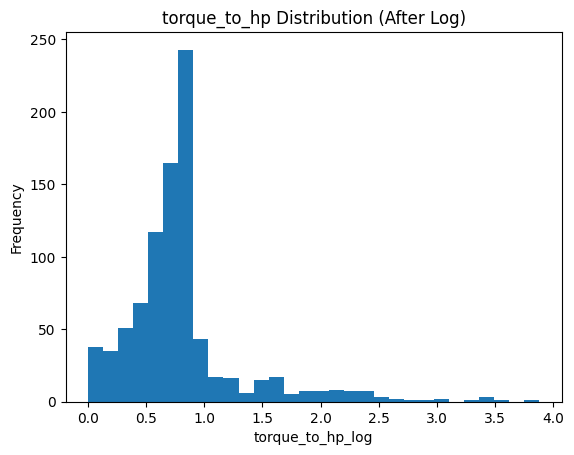

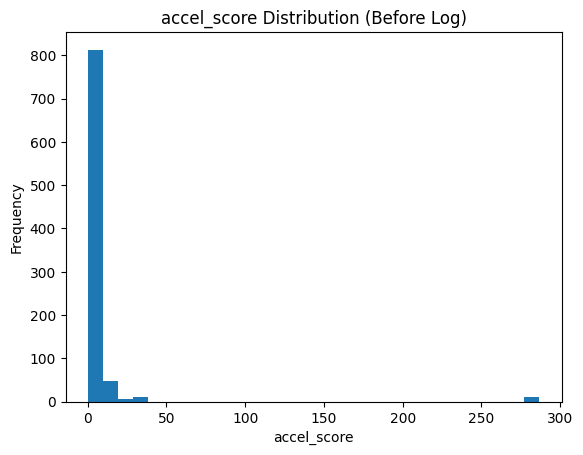

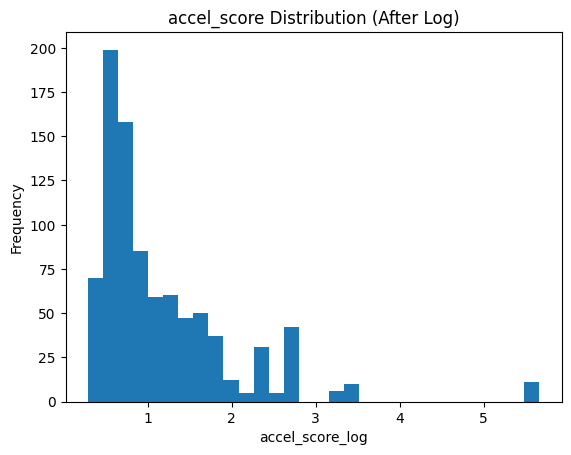

In [52]:
# --- Simple EDA visualizations for engineered features ---
import matplotlib.pyplot as plt

# Choose a few key features to inspect visually
features_to_plot = ['hp_num', 'cc_num', 'torque_num',
                    'hp_per_cc', 'torque_to_hp', 'accel_score']

for feature in features_to_plot:
    if feature in df.columns:
        # Histogram before log transform
        plt.hist(df[feature].dropna(), bins=30)
        plt.title(f"{feature} Distribution (Before Log)")
        plt.xlabel(feature)
        plt.ylabel("Frequency")
        plt.show()

        # If a log-transformed version exists, plot it
        log_col = f"{feature}_log"
        if log_col in df.columns:
            plt.hist(df[log_col].dropna(), bins=30)
            plt.title(f"{feature} Distribution (After Log)")
            plt.xlabel(log_col)
            plt.ylabel("Frequency")
            plt.show()




In [55]:
import numpy as np


numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns detected:", numeric_cols)


if len(numeric_cols) < 2:
    print("Not enough numeric columns for correlation-based selection.")
else:

    corr = df[numeric_cols].corr().abs()
    print("\nAbsolute correlation matrix:\n", corr)


    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    threshold = 0.90
    to_drop = set()


    def mean_corr_excluding_self(col_name):
        n = len(corr)
        return (corr[col_name].sum() - 1.0) / (n - 1)

    numeric_list = numeric_cols
    for i in range(len(numeric_list)):
        for j in range(i + 1, len(numeric_list)):
            a = numeric_list[i]
            b = numeric_list[j]
            if corr.loc[a, b] > threshold:

                if mean_corr_excluding_self(a) > mean_corr_excluding_self(b):
                    to_drop.add(a)
                else:
                    to_drop.add(b)

    to_drop = sorted(list(to_drop))
    print("\nFeatures to drop (corr > {}):".format(threshold), to_drop)


    df_reduced = df.drop(columns=to_drop)


Numeric columns detected: ['CC/Battery Capacity', 'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Torque', 'torque_num', 'hp_num', 'cc_num', 'accel_num', 'hp_per_cc', 'accel_score', 'torque_to_hp', 'hp_per_cc_log', 'accel_score_log', 'torque_to_hp_log', 'hp_num_log', 'cc_num_log', 'accel_num_log', 'torque_num_log']

Absolute correlation matrix:
                            CC/Battery Capacity  HorsePower  Total Speed  \
CC/Battery Capacity                   1.000000    0.647633     0.446642   
HorsePower                            0.647633    1.000000     0.785887   
Total Speed                           0.446642    0.785887     1.000000   
Performance(0 - 100 )KM/H             0.439085    0.824688     0.807737   
Torque                                0.623526    0.903732     0.620189   
torque_num                            0.248070    0.393320     0.168517   
hp_num                                0.277302    0.533001     0.418176   
cc_num                                0.

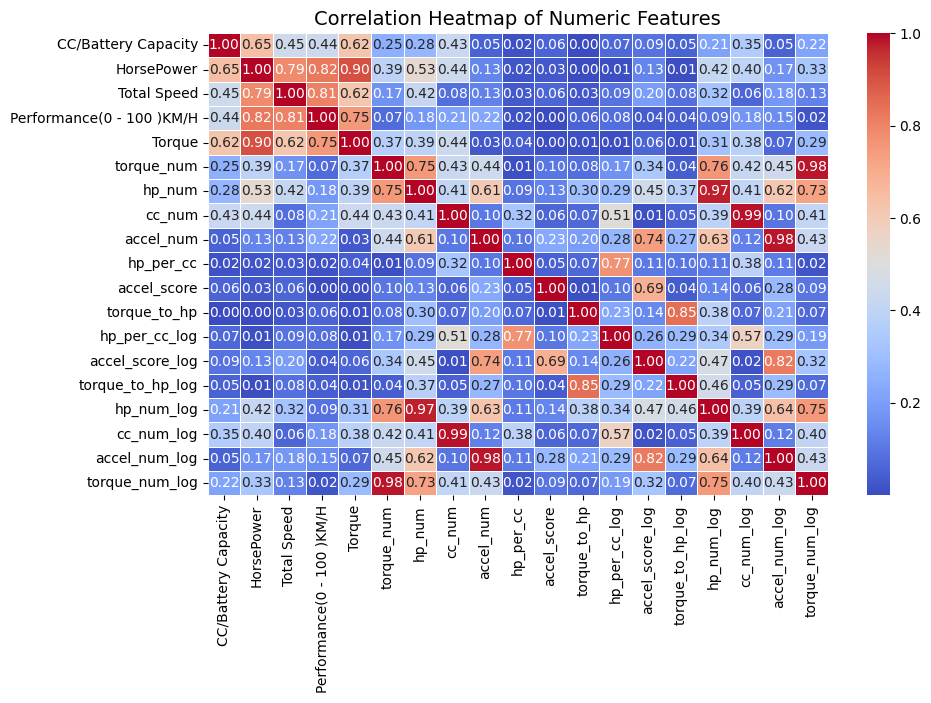

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True,linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.show()